# 通信事業者の月次ネットワークKPI:データ使用量の棒グラフとARPU・解約率の折れ線(PROC GBARLINE)

## エグゼクティブサマリー

このノートブックは**PROC GBARLINE**を使い、月次モバイルデータ使用量の縦棒グラフに、ARPU・解約率・サポートチケットの折れ線を重ね合わせる——通信アナリストが、使用量の増加が実際に収益と顧客維持につながっているかを見極めるために構築する、古典的な「二軸」KPIダッシュボードである。契約者単位の合成レコードをインラインで生成し、サブグループ、カスタム右軸、参照シンボル、凡例を伴うBARおよびLINEステートメントを実演する。

## データソース

**データセット:`telco_kpi`** — 契約者×月別の合成レコード(4か月 x 3プランティア x 8契約者 = 96行)。`call streaminit(20260531)`でインラインに生成される。パネルは96行に抑えられており、unlicensedモードの100件制限に余裕を持って収まり、すべての月・プランティアが完全に埋まる。

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `month`  | 文字 | 暦月ラベル(1月〜4月) |
| `plan`   | 文字 | プランティア:プリペイド、ポストペイド、ファミリー |
| `data_gb`| 数値 | 月次モバイルデータ使用量(GB、ガンマ分布、緩やかな季節リフトと緩やかな成長を伴う) |
| `arpu`   | 数値 | ユーザー当たり平均収益(USD、プランティアが上がるほど、また月が進むほど上昇) |
| `churn`  | 数値 | 月次解約フラグ(0/1、ベルヌーイ分布。期間の前半とより低いティアで高い) |
| `tickets`| 数値 | 開設されたサポートチケット数(ポアソン計数) |

# PROC GBARLINEによる通信事業者の月次ネットワークKPI

通信事業者の浮沈は、ひと握りの月次KPIにかかっている:契約者がどれだけの**データ**を消費するか、その消費が生む**ARPU**(ユーザー当たり平均収益)、何人の顧客が**解約**するか、そしてその背後にある**サポートチケット**の負荷である。これらの指標は、ギガバイト、ドル、そして小さな件数という全く異なる尺度に存在するため、単一の応答軸にプロットするとストーリーが見えなくなる。

`PROC GBARLINE`はまさにこのために作られている:左軸に対して縦**棒**グラフを描き、独立した右軸に対して1つ以上の**折れ線**を重ねる。このノートブックでは、使用量対収益のダッシュボードを構築し、その後プランレベルのサブグループ、カスタム右軸、複数折れ線の重ね合わせを段階的に追加する。

## ステップ1 — 合成の契約者×月データを生成する

以下のDATAステップは、現実的なパネルを作り出す:4か月(1月〜4月)×3プランティア(プリペイド、ポストペイド、ファミリー)×各8契約者、合計96行。再現性のため`call streaminit`で乱数種を固定し、各KPIをドメインに適した分布から抽出する:

- **データ使用量**はガンマ分布から、緩やかな季節リフトと緩やかな月次成長を伴って生成する。
- **ARPU**はプランティアが上がるほど、また月が進むほど上昇し、正規分布のノイズを伴う。
- **解約**は、期間の前半と安価なティアでより高くなるベルヌーイフラグとする。
- **サポートチケット**はポアソン計数とし、前半にやや重くなる。

外部ファイルは一切読み込まれない——すべて自己完結しており、96行のパネルはunlicensedの100件上限に収まるため、すべての月・ティアが描画される。

In [1]:
データ telco_kpi;
    呼出 streaminit(20260531);
    長さ month $6 plan $20;
    繰返 mi = 1 から 4;
        もし      mi = 1 なら month = "1月";
        他 もし mi = 2 なら month = "2月";
        他 もし mi = 3 なら month = "3月";
        他                 month = "4月";
        /* 緩やかな季節リフトと緩やかなデータ成長 */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        繰返 plan_i = 1 から 3;
            もし plan_i = 1 なら plan = "プリペイド";
            他 もし plan_i = 2 なら plan = "ポストペイド";
            他 plan = "ファミリー";
            繰返 rep = 1 から 8;
                /* 月次モバイルデータ使用量(GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* ユーザー当たり平均収益($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* 月次解約フラグ、年初ほど高い */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* 開設されたサポートチケット数 */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                出力;
            終了;
        終了;
    終了;
    削除 mi plan_i rep season;
実行;



NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## ステップ2 — コアダッシュボード:使用量の棒とARPUの折れ線

これが典型的な`GBARLINE`のパターンである。`BAR`ステートメントは月次平均データ使用量(`SUMVAR=data_gb TYPE=mean`)をチャートし、単一の`LINE`ステートメントが右軸に平均ARPU(`STAT=mean TYPE=join`)を重ねる。ODSグラフィックスを有効にし、チャートに2行タイトルを付ける。`COUTLINE=`と`WIDTH=`で棒を整える。

                                                   月次モバイルデータ使用量とARPU                                                    
                                                  通信事業者ネットワークKPIの合成データ                                                  




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to 月次モバイルデータ使用量とARPU.
NOTE: Option TITLE2 changed to 通信事業者ネットワークKPIの合成データ.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


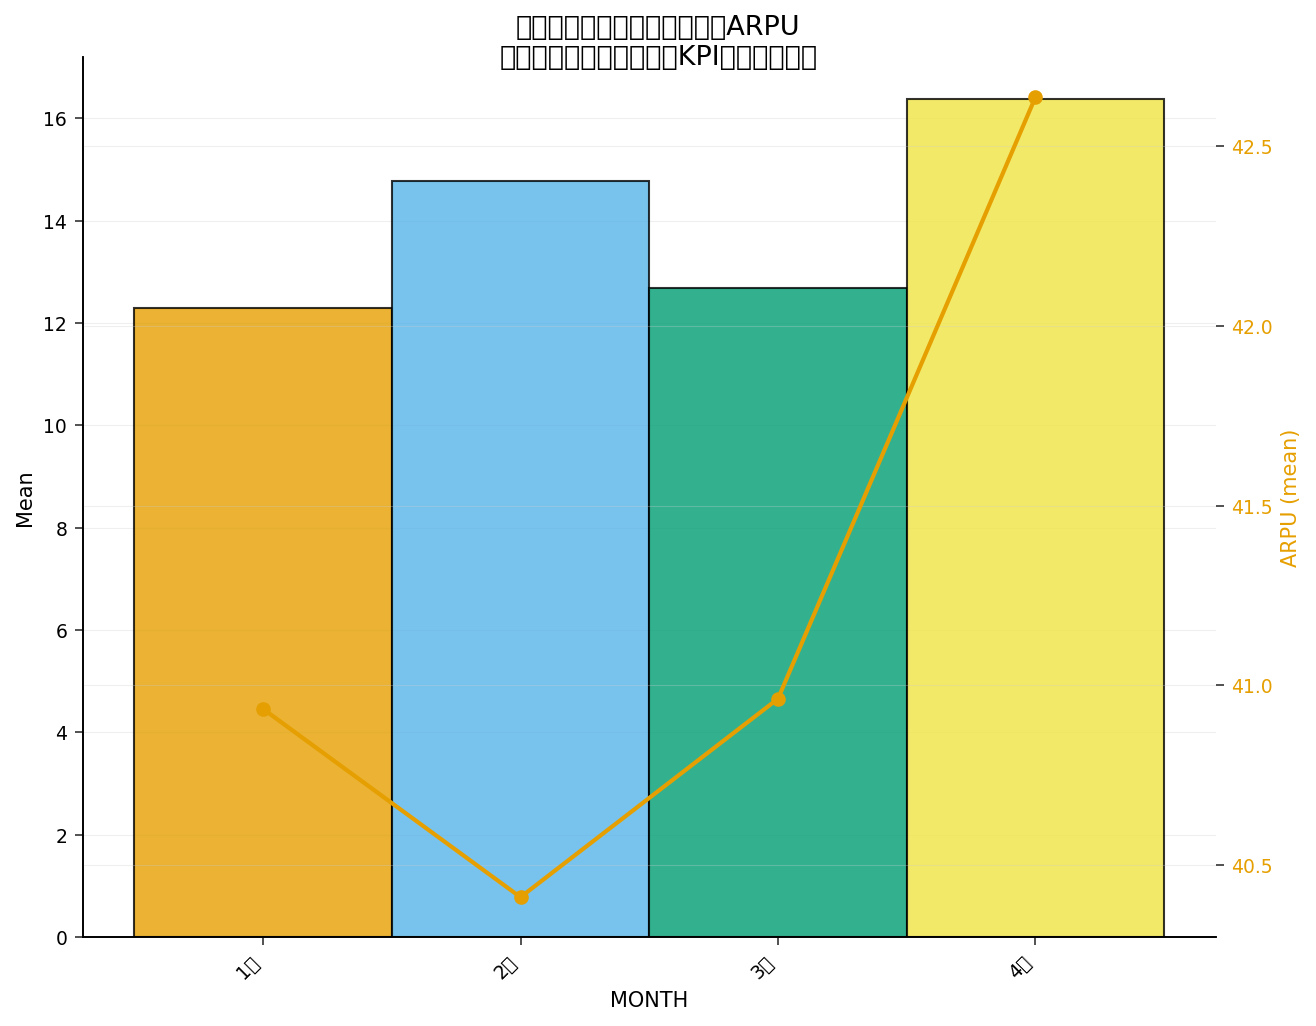

In [2]:
ODS GRAPHICS ON;
表題 "月次モバイルデータ使用量とARPU";
title2 "通信事業者ネットワークKPIの合成データ";

処理 gbarline データ=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
実行;


## ステップ3 — 使用量をプラン別に分解し、解約を重ねる

`TYPE=mean`を`TYPE=sum`に置き換え、`SUBGROUP=plan`を追加すると、各月の棒がプランティア別に積み上げられ、どのセグメントが総量を牽引しているかが分かる。重ねた`LINE`は、解約イベントの月次**件数**をニードルプロット(`STAT=sum TYPE=needle`)として描画する——なめらかなトレンドではなく離散的なイベント件数として自然に読み取れる垂直のスパイクである。

                                                     プラン別データ量と月次解約                                                      
                                                  通信事業者ネットワークKPIの合成データ                                                  




NOTE: Option TITLE changed to プラン別データ量と月次解約.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


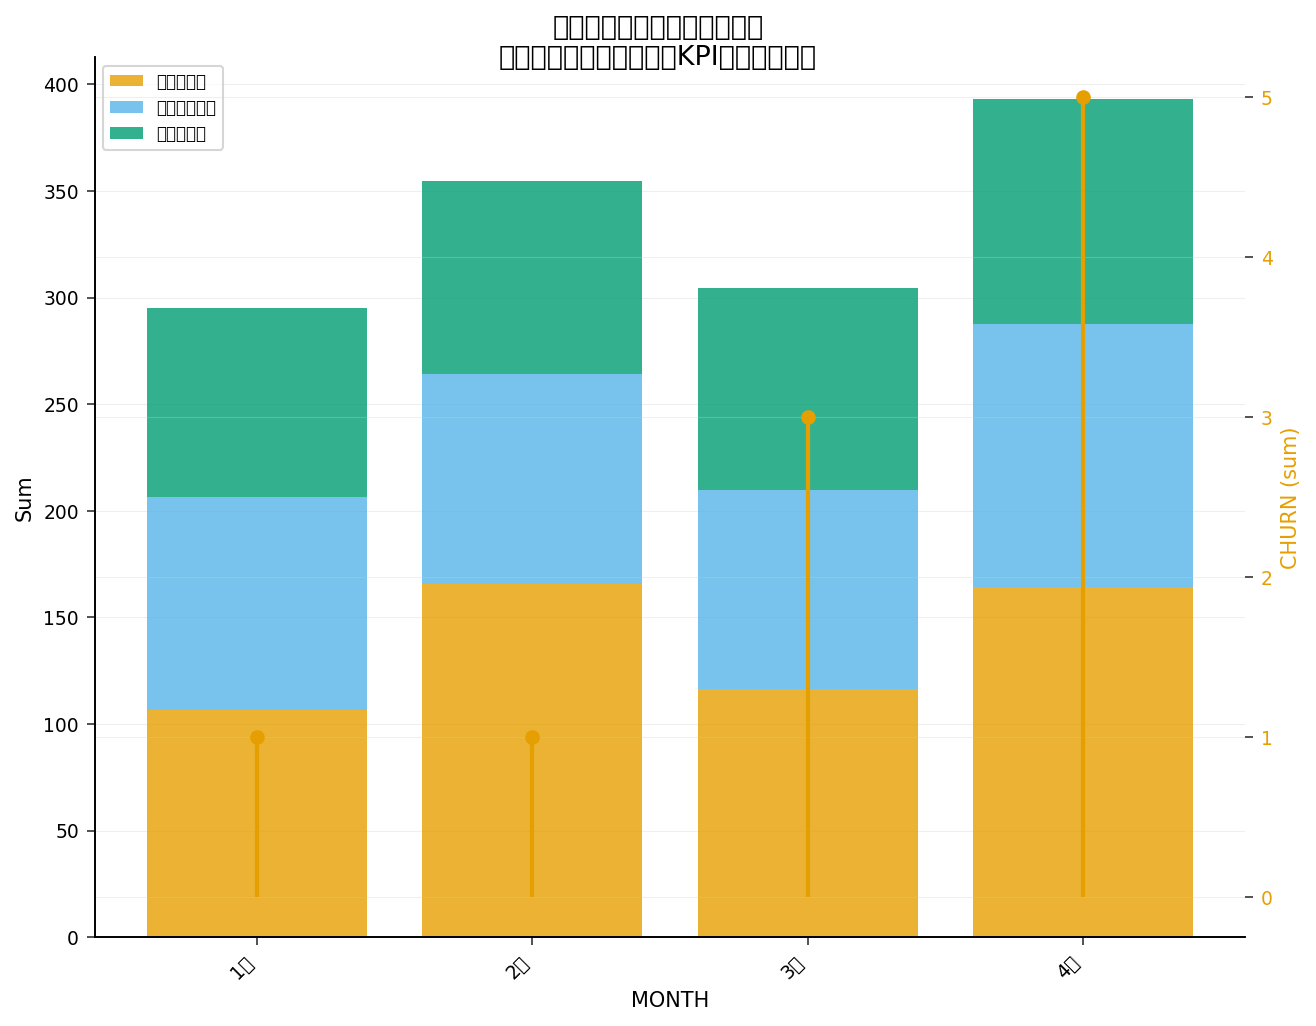

In [3]:
表題 "プラン別データ量と月次解約";

処理 gbarline データ=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
実行;


## ステップ4 — 右軸と折れ線マーカーを制御する

発表用の仕上がりにするため、`AXIS`定義でプロット(右)軸を固定範囲に固定してラベルを付け、`RAXIS=axis2`で折れ線に結び付ける。`SYMBOL`定義がARPUの折れ線に赤い点線マーカーを与える。また`OUTSIDE=sum`で各棒の上に棒の合計値を表示する。

                                                  総使用量(棒)対平均ARPU(折れ線)                                                   
                                                  通信事業者ネットワークKPIの合成データ                                                  




NOTE: Option TITLE changed to 総使用量(棒)対平均ARPU(折れ線).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


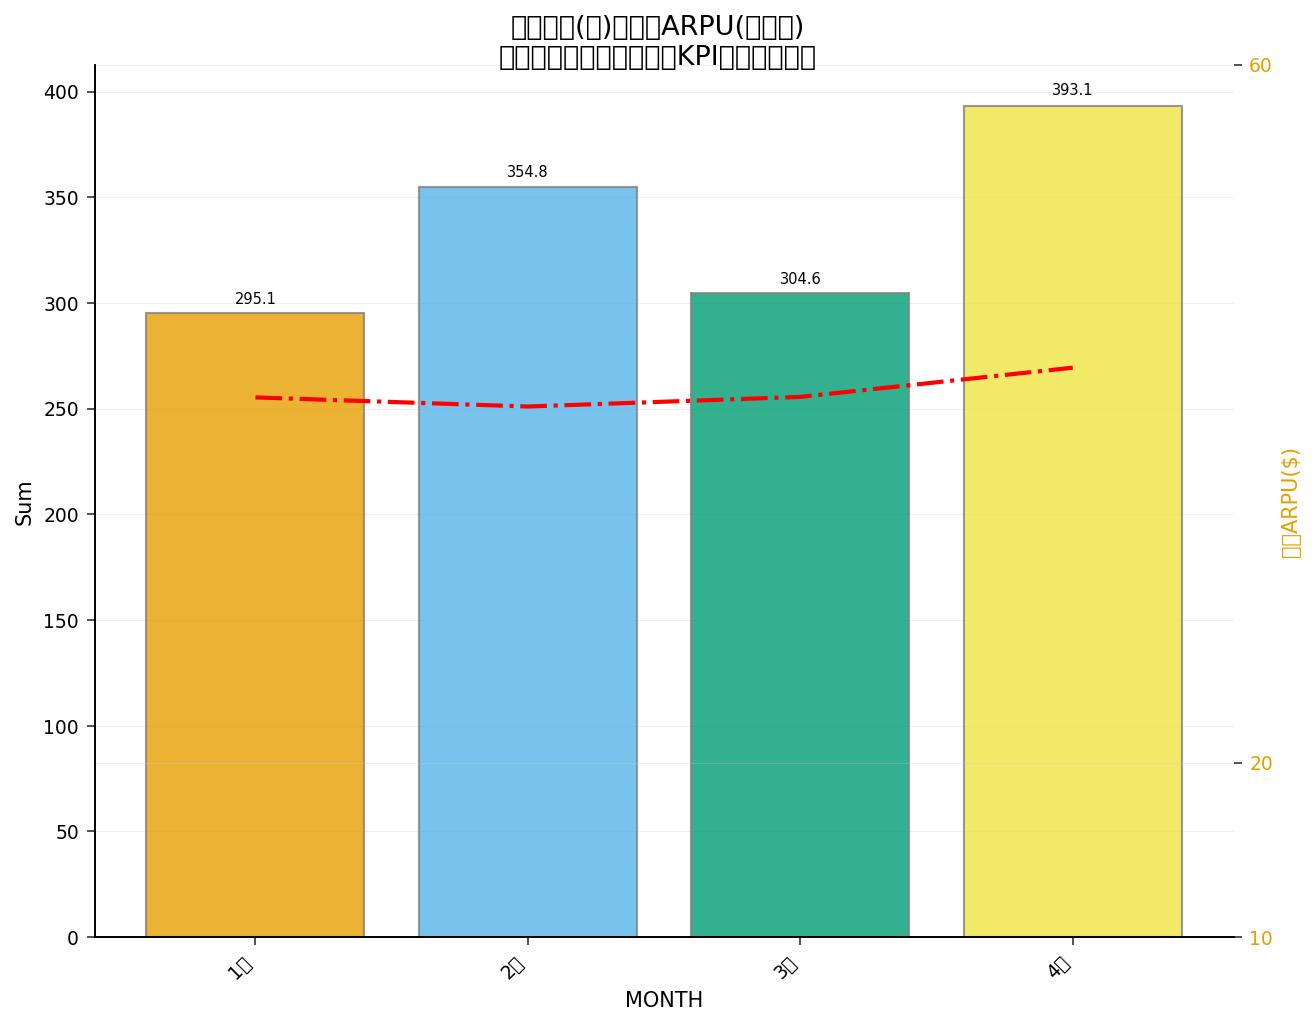

In [4]:
表題 "総使用量(棒)対平均ARPU(折れ線)";

処理 gbarline データ=telco_kpi;
    axis2 ORDER=(20 から 60 基準 10) 見出=("平均ARPU($)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
実行;


## ステップ5 — カスタム凡例を伴う複数折れ線の重ね合わせ

`GBARLINE`は複数の`LINE`ステートメントを受け付けるため、使用量の棒に対して2つの運用シグナルを同時に比較できる:平均サポートチケット数(`type=join`)と解約総数(`type=needle`)である。下部に配置した`LEGEND`定義がプランサブグループを説明する。

                                                     サポートチケットと解約の推移                                                     
                                                  通信事業者ネットワークKPIの合成データ                                                  




NOTE: Option TITLE changed to サポートチケットと解約の推移.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


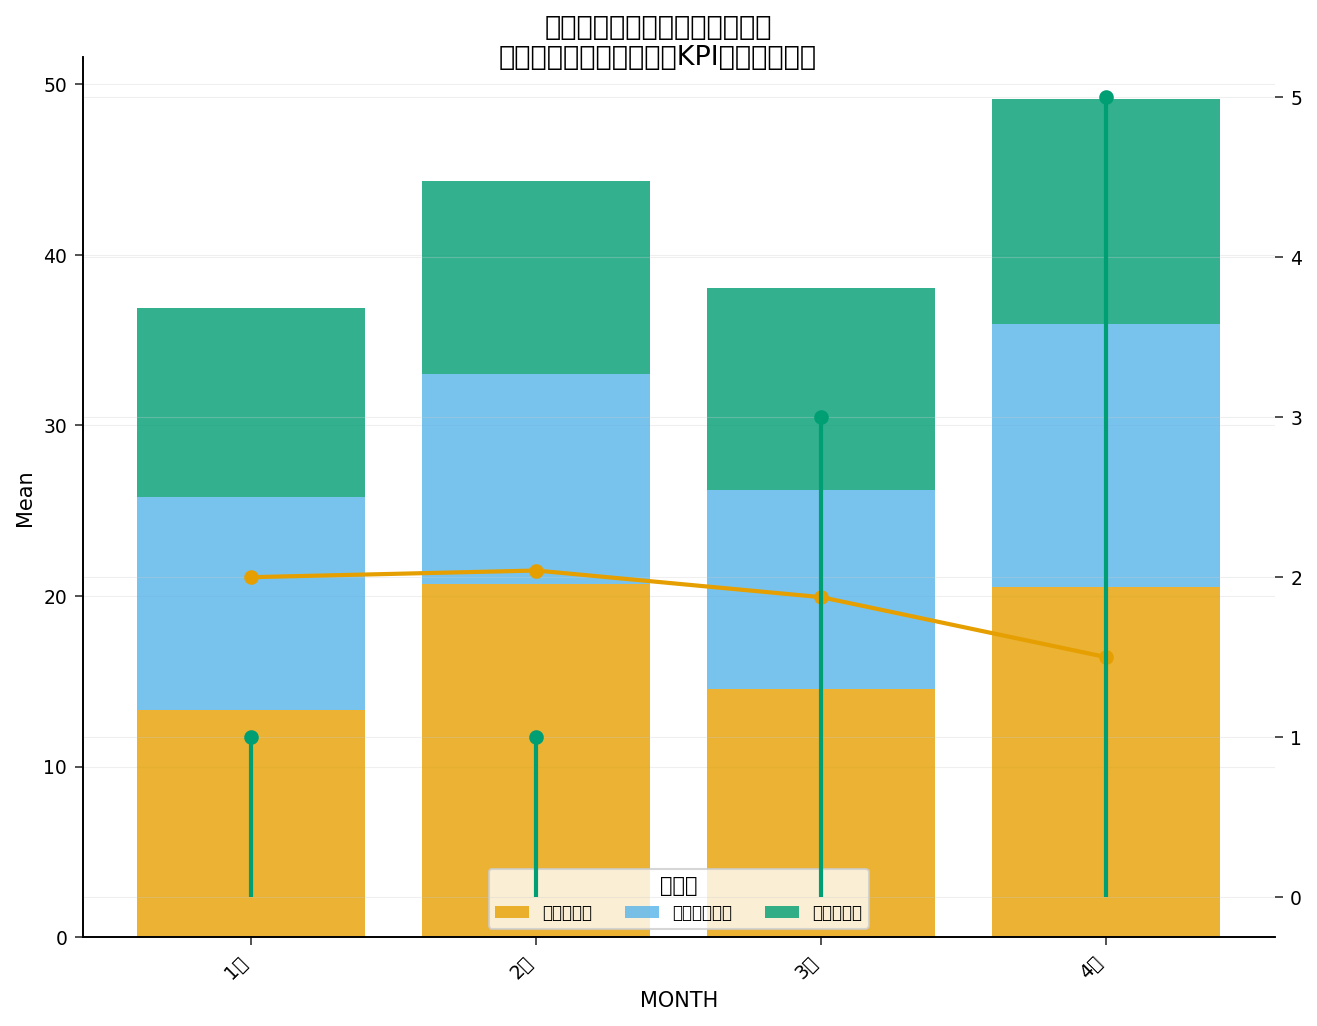

In [5]:
表題 "サポートチケットと解約の推移";

処理 gbarline データ=telco_kpi;
    legend1 見出=("プラン") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
実行;

ODS GRAPHICS OFF;


## 結果の解釈

1月から4月の期間を通じて、ダッシュボードは一貫した通信事業のストーリーを語る。**データ使用量**(棒)は月によって変動があるものの上昇傾向にあり、**4月**にピークを迎える——平均使用量は1月の約12.3GBから4月には16.4GBまで上昇し(ステップ2)、総量は295GBから393GBまで増える(ステップ4の`OUTSIDE=sum`ラベル)。**ARPUの折れ線**は2月にわずかに落ち込んだ後、4月には自身の最高値である約\$42.6まで上昇する。つまり事業者は、増加した消費を無償で提供するのではなく、徐々に収益化できている——ステップ4の右軸は、その動きを読み取りやすくするため\$20〜\$60に固定されている。

プラン別積み上げビュー(ステップ3と5)は、プリペイド比率の高いキャリアを特徴づけるセグメント間の緊張関係を明らかにする。**プリペイド**(オレンジの帯)は全体で最も多くのギガバイトを運ぶ——4か月合計でおよそ553GBに対し、ポストペイドは415GB、ファミリーは380GB——にもかかわらず、ユーザー当たり平均収益は**最も低い**(約\$36、ポストペイドの\$41、ファミリーの\$47に対して)。**解約のニードル**は、顧客維持リスクがどこにあるかを裏付ける:解約イベントはプリペイドとポストペイドのティアに集中し(期間を通じてそれぞれ4件)、ファミリーでは少ない(2件)。そして契約者基盤と使用量が拡大するにつれ、4月に向けて増加する。

ステップ5はこの上に運用負荷を重ねる:平均**サポートチケット**は期間の前半にやや重く、4月にかけて緩和する一方、解約のニードルはより遅くピークを迎える——顧客維持チームが注視すべき類のシグナルである。運用上の読み取りは、データ量の中で最も急速に伸びる部分を消費しながら、収益が最も少なく解約が最も多い**プリペイド**契約者に、顧客維持のための支出を集中させることである。

`PROC GBARLINE`がここで適切なツールであるのは、まさにギガバイト尺度の棒とドル/件数尺度の折れ線を独立した軸に保ちながら、各KPIをそれぞれの尺度で読み取れるようにし、それでいて月次の時間軸を共有できるからである。